<a href="https://colab.research.google.com/github/nexageapps/AI/blob/main/Basic/B05%20-%20Neural%20Network%20Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lesson 5: Neural Network Fundamentals


## Learning Objectives
- Understand multi-layer perceptrons (MLPs)
- Learn about hidden layers and their purpose
- Explore activation functions (ReLU, tanh, sigmoid)
- Understand overfitting vs underfitting
- Implement dropout and regularization

## Prerequisites
- Completed L1-L5
- Understanding of multi-class classification

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns

print(f"TensorFlow version: {tf.__version__}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

2026-03-14 13:09:39.609751: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.16.2


## 1. Why Do We Need Hidden Layers?

In L5, we used a single layer (input → output).  
This is called a **linear model** and can only learn linear patterns.

**Problem:** Real-world data is rarely linear!

**Solution:** Add hidden layers to learn complex, non-linear patterns.

### Architecture Evolution:
- **L5:** Input (784) → Output (10)
- **L6:** Input (784) → Hidden (128) → Output (10)

## 2. Understanding Activation Functions

Activation functions introduce **non-linearity** into the network.

Without activation functions, multiple layers = one layer (just matrix multiplication).

### Common Activation Functions:
1. **ReLU** (Rectified Linear Unit): `f(x) = max(0, x)`
2. **Sigmoid**: `f(x) = 1 / (1 + e^(-x))`
3. **Tanh**: `f(x) = (e^x - e^(-x)) / (e^x + e^(-x))`
4. **Softmax**: Used for output layer in multi-class classification

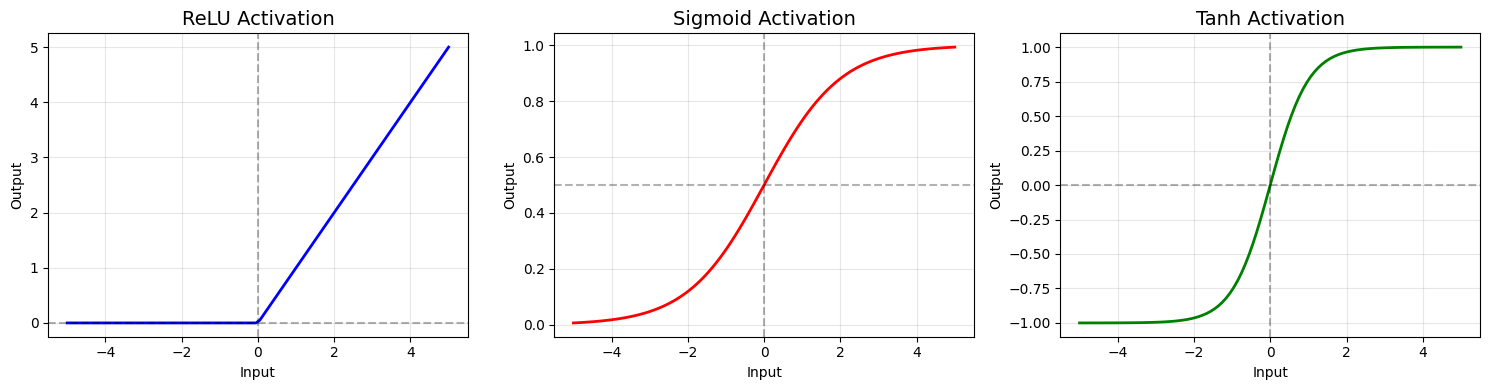

Activation Function Properties:

ReLU:
  - Range: [0, ∞)
  - Fast to compute
  - Most popular for hidden layers
  - Can suffer from 'dying ReLU' problem

Sigmoid:
  - Range: (0, 1)
  - Good for binary classification output
  - Can cause vanishing gradients

Tanh:
  - Range: (-1, 1)
  - Zero-centered (better than sigmoid)
  - Can also cause vanishing gradients


In [3]:
# Visualize activation functions
x = np.linspace(-5, 5, 100)

# Define activation functions
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

# Plot
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(x, relu, 'b-', linewidth=2)
plt.title('ReLU Activation', fontsize=14)
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(x, sigmoid, 'r-', linewidth=2)
plt.title('Sigmoid Activation', fontsize=14)
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(True, alpha=0.3)
plt.axhline(y=0.5, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.subplot(1, 3, 3)
plt.plot(x, tanh, 'g-', linewidth=2)
plt.title('Tanh Activation', fontsize=14)
plt.xlabel('Input')
plt.ylabel('Output')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='--', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("Activation Function Properties:")
print("\nReLU:")
print("  - Range: [0, ∞)")
print("  - Fast to compute")
print("  - Most popular for hidden layers")
print("  - Can suffer from 'dying ReLU' problem")

print("\nSigmoid:")
print("  - Range: (0, 1)")
print("  - Good for binary classification output")
print("  - Can cause vanishing gradients")

print("\nTanh:")
print("  - Range: (-1, 1)")
print("  - Zero-centered (better than sigmoid)")
print("  - Can also cause vanishing gradients")

## 3. Load and Prepare Data

In [ ]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize and flatten
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode labels
y_train_onehot = keras.utils.to_categorical(y_train, 10)
y_test_onehot = keras.utils.to_categorical(y_test, 10)

print(f"Training data shape: {x_train.shape}")
print(f"Test data shape: {x_test.shape}")

## 4. Build a Multi-Layer Neural Network

Let's compare different architectures:
1. Single layer (from L5)
2. One hidden layer
3. Two hidden layers

In [ ]:
# Model 1: Single Layer (No hidden layers)
model_single = keras.Sequential([
    layers.Dense(10, activation='softmax', input_shape=(784,))
], name='Single_Layer')

# Model 2: One Hidden Layer
model_one_hidden = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
], name='One_Hidden_Layer')

# Model 3: Two Hidden Layers
model_two_hidden = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='Two_Hidden_Layers')

# Compile all models
for model in [model_single, model_one_hidden, model_two_hidden]:
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

print("Model 1: Single Layer")
model_single.summary()
print("\n" + "="*50 + "\n")

print("Model 2: One Hidden Layer")
model_one_hidden.summary()
print("\n" + "="*50 + "\n")

print("Model 3: Two Hidden Layers")
model_two_hidden.summary()

## 5. Train and Compare Models

In [ ]:
# Train all models
models = [model_single, model_one_hidden, model_two_hidden]
histories = []

for i, model in enumerate(models):
    print(f"\nTraining {model.name}...")
    history = model.fit(
        x_train, y_train_onehot,
        epochs=10,
        batch_size=128,
        validation_split=0.2,
        verbose=0
    )
    histories.append(history)
    
    # Evaluate
    test_loss, test_acc = model.evaluate(x_test, y_test_onehot, verbose=0)
    print(f"{model.name} - Test Accuracy: {test_acc*100:.2f}%")

In [ ]:
# Plot comparison
plt.figure(figsize=(15, 5))

# Training accuracy
plt.subplot(1, 2, 1)
for i, (model, history) in enumerate(zip(models, histories)):
    plt.plot(history.history['accuracy'], label=model.name)
plt.title('Training Accuracy Comparison', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Validation accuracy
plt.subplot(1, 2, 2)
for i, (model, history) in enumerate(zip(models, histories)):
    plt.plot(history.history['val_accuracy'], label=model.name)
plt.title('Validation Accuracy Comparison', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Understanding Overfitting vs Underfitting

### Underfitting:
- Model is too simple
- Poor performance on both training and test data
- **Solution:** Add more layers/neurons, train longer

### Overfitting:
- Model is too complex
- Great on training data, poor on test data
- **Solution:** Regularization, dropout, more data

### Good Fit:
- Good performance on both training and test data
- Small gap between training and validation accuracy

In [ ]:
# Demonstrate overfitting with a very deep network
model_overfit = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
], name='Overfitting_Model')

model_overfit.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training overfitting-prone model...")
history_overfit = model_overfit.fit(
    x_train, y_train_onehot,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=0
)

# Plot overfitting
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_overfit.history['accuracy'], label='Training')
plt.plot(history_overfit.history['val_accuracy'], label='Validation')
plt.title('Overfitting Example - Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_overfit.history['loss'], label='Training')
plt.plot(history_overfit.history['val_loss'], label='Validation')
plt.title('Overfitting Example - Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nNotice how training accuracy keeps improving,")
print("but validation accuracy plateaus or decreases.")
print("This is a clear sign of OVERFITTING!")

## 7. Preventing Overfitting: Dropout

**Dropout** randomly "drops" neurons during training.
- Prevents neurons from co-adapting
- Acts as regularization
- Typical dropout rate: 0.2 - 0.5

In [ ]:
# Model with dropout
model_dropout = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(784,)),
    layers.Dropout(0.3),  # Drop 30% of neurons
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
], name='Model_with_Dropout')

model_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training model with dropout...")
history_dropout = model_dropout.fit(
    x_train, y_train_onehot,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=0
)

# Compare with and without dropout
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_overfit.history['val_accuracy'], label='Without Dropout', linewidth=2)
plt.plot(history_dropout.history['val_accuracy'], label='With Dropout', linewidth=2)
plt.title('Effect of Dropout on Validation Accuracy', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_overfit.history['val_loss'], label='Without Dropout', linewidth=2)
plt.plot(history_dropout.history['val_loss'], label='With Dropout', linewidth=2)
plt.title('Effect of Dropout on Validation Loss', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Optimal Model Architecture

Let's build an optimal model with:
- Appropriate depth (2 hidden layers)
- Dropout for regularization
- Batch normalization for faster training

In [ ]:
# Optimal model
model_optimal = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(784,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(10, activation='softmax')
], name='Optimal_Model')

model_optimal.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_optimal.summary()

# Train
print("\nTraining optimal model...")
history_optimal = model_optimal.fit(
    x_train, y_train_onehot,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Evaluate
test_loss, test_acc = model_optimal.evaluate(x_test, y_test_onehot)
print(f"\nFinal Test Accuracy: {test_acc*100:.2f}%")

## 9. Visualize Model Predictions

In [ ]:
# Make predictions
predictions = model_optimal.predict(x_test[:20].reshape(-1, 784))

# Visualize
plt.figure(figsize=(15, 6))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]
    confidence = predictions[i][pred_label] * 100
    
    color = 'green' if pred_label == true_label else 'red'
    plt.title(f"P:{pred_label} ({confidence:.0f}%)\nT:{true_label}", 
              color=color, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

## 10. Key Takeaways

### Architecture:
1. **Hidden layers** enable learning complex patterns
2. **ReLU** is the most common activation for hidden layers
3. **Deeper ≠ Better** - balance complexity with overfitting

### Training:
4. **Overfitting** occurs when model memorizes training data
5. **Dropout** prevents overfitting by randomly dropping neurons
6. **Batch Normalization** speeds up training and improves stability

### Best Practices:
7. Start simple, add complexity gradually
8. Monitor validation metrics to detect overfitting
9. Use dropout rates between 0.2-0.5
10. Experiment with different architectures

## Next Steps (L7)
- Learn about Convolutional Neural Networks (CNNs)
- Understand why CNNs are better for images
- Implement convolution and pooling layers

## References
- Deep Learning Book: https://www.deeplearningbook.org/
- CS231n Stanford: http://cs231n.stanford.edu/
- TensorFlow Tutorials: https://www.tensorflow.org/tutorials

---

## Key Takeaways

**Relevant UoA Courses:** COMPSCI 713, COMPSCI 762, COMPSYS 721

1. MLPs have input layer, hidden layer(s), and output layer
2. Each layer: z = Wx + b, then a = activation(z)
3. ReLU activation: f(x) = max(0, x) - most common for hidden layers
4. Backpropagation computes gradients layer by layer using chain rule
5. Universal approximation theorem: MLPs can approximate any function

---

## Exam Preparation Guide

### Essential Concepts for Exams

- Trace forward pass through network: input → hidden → output
- Calculate number of parameters: (input_dim × hidden_dim) + hidden_dim + ...
- Understand vanishing gradient problem with sigmoid/tanh
- Know why ReLU is preferred: no vanishing gradient, computationally efficient
- Be able to apply chain rule for backpropagation

### Common Mistakes to Avoid

- ❌ Forgetting bias terms when counting parameters
- ❌ Using sigmoid in hidden layers (causes vanishing gradients)
- ❌ Not understanding that deeper ≠ always better

### Practice Problems

1. Network: 784 → 128 → 64 → 10. How many parameters?
2. Given ReLU(Wx + b) where x=[1,-2], W=[[2,1]], b=[0], compute output
3. Explain why ReLU(x) = max(0,x) helps with vanishing gradients

### How This Helps Your UoA Courses

**COMPSCI 713, COMPSCI 762, COMPSYS 721:**
- Provides hands-on implementation of theoretical concepts
- Practice problems similar to exam questions
- Reinforces lecture material with code examples
- Helps build intuition for complex topics

### Study Tips

1. **Understand, Don't Memorize**: Focus on why, not just what
2. **Practice Calculations**: Work through problems by hand
3. **Connect to Theory**: Link code to mathematical formulations
4. **Teach Others**: Explaining concepts solidifies understanding
5. **Review Regularly**: Spaced repetition improves retention

### Exam Question Types

- **Conceptual**: Explain why/how something works
- **Calculation**: Compute outputs, gradients, shapes
- **Comparison**: Compare approaches, trade-offs
- **Application**: Design solution for given problem
- **Debugging**: Identify and fix issues

---


---

## Learning Progress Tracker

Use this section to track your learning progress for this lesson.

### Completion Status
- [ ] Lesson completed
- [ ] All code cells executed successfully
- [ ] Understood all key concepts
- [ ] Completed practice exercises (if any)

### Dates
- **First Completed:** ____/____/____
- **Last Reviewed:** ____/____/____
- **Next Review:** ____/____/____ (Recommended: 1 week, 1 month, 3 months)

### Understanding Level
Rate your understanding (1-5): _____ / 5

- 1 = Need to review completely
- 2 = Understood basics, need more practice
- 3 = Good understanding, minor gaps
- 4 = Strong understanding, can explain to others
- 5 = Mastered, can apply in projects

### Notes & Reflections
```
Write your notes here:
- What concepts were challenging?
- What was interesting or surprising?
- How can you apply this in projects?
- Questions to explore further?




```

### Key Concepts to Remember (B05)
- [ ] Multi-layer perceptrons (MLPs)
- [ ] Activation functions (ReLU, sigmoid, tanh)
- [ ] Backpropagation algorithm
- [ ] Forward and backward passes

---